# 2 — The solver, checked against an exact solution

`groundtruth` solves the scalar transmission problem
$(\nabla^2+k^2)\psi=0$ with $[\psi]=0$, $[\partial_n\psi]=0$ on a body of
revolution, using a Müller second-kind boundary-integral formulation reduced
to the $m=0$ azimuthal harmonic.

The homogeneous ball has a closed-form solution by separation of variables
(the scalar analogue of Mie), so it fixes the solver's error with no
reference to any optical model.  Two things are established here: the
convergence rate, and the range of electrical size where the solver is
usable.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
from nbstyle import *

import time
from groundtruth.bem import (sphere_generator, solve_muller, field_map,
                             field_interior)
from groundtruth.exact import ScalarBall

LAM = 1.0

## Convergence on the surface

Plane wave on a ball of radius $2\lambda$, $n_2=1.5$.  The error is the
maximum relative difference between the BEM surface field $u$ and the exact
series.

In [2]:
def ball_error(a, n2, N, n1=1.0):
    b = ScalarBall(n1, n2, a, LAM)
    g = sphere_generator(a, N)
    if (g.n_rho * g.rho + g.n_z * g.z).mean() < 0:
        g.flip_normal()
    ui = np.exp(1j * b.k1 * g.z)
    vi = 1j * b.k1 * g.n_z * ui
    u, v, _ = solve_muller(g, b.k1, b.k2, ui, vi)
    ue = b.surface_field(g.z / a)
    return np.abs(u - ue).max() / np.abs(ue).max()

Ns = np.array([100, 200, 400, 800])
errs = np.array([ball_error(2.0, 1.5, int(N)) for N in Ns])
for N, e in zip(Ns, errs):
    print(f"N = {N:4d}   error = {e:.3e}")
p = np.polyfit(np.log(Ns[:3]), np.log(errs[:3]), 1)[0]
print(f"\nobserved order over the first three meshes: h^{-p:.2f}")

N =  100   error = 4.608e-02
N =  200   error = 7.480e-03
N =  400   error = 2.450e-03
N =  800   error = 1.243e-03

observed order over the first three meshes: h^2.12


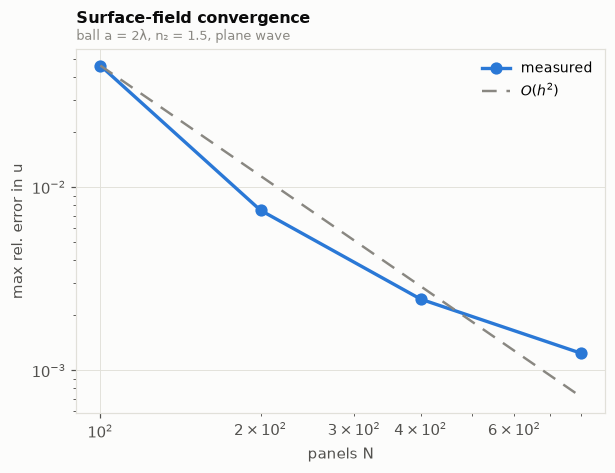

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 4.3))
ax.loglog(Ns, errs, "o-", color=BLUE, lw=2.2, ms=7, label="measured")
ax.loglog(Ns, errs[0] * (Ns / Ns[0]) ** -2.0, ls=(0, (6, 4)), color=MUTED,
          lw=1.6, label="$O(h^2)$")
ax.set_xlabel("panels N"); ax.set_ylabel("max rel. error in u")
ax.legend(fontsize=9)
ttl(ax, "Surface-field convergence", "ball a = 2λ, n₂ = 1.5, plane wave")
plt.show()

## The field inside and outside, and the limit in electrical size

The large ball ($a = 6\lambda$, $n_2 = 2.5$, $k_1 a = 37.7$) is far beyond
the BEM's resolution limit at $N = 900$ panels — the interior field is
visibly noisy and the pointwise error exceeds 200 %.  The convergence
envelope (below) shows where the 1 % threshold is crossed.

In [ ]:
BL = load("ball_fields")
MC = load("method_check")
aa = float(BL["a"])
inside_bl = BL["inside"]
valid_bl = inside_bl | BL["outside"] if "outside" in BL else inside_bl

fig, ax = plt.subplots(2, 2, figsize=(14.0, 11.0))
circ = np.linspace(0, 2 * np.pi, 400)

# -- top row: exact | BEM on linear scale --
rr_ex, PP_ex = mirror(BL["rg"], BL["psi"])
vmax = np.nanpercentile(np.abs(PP_ex), 97)

for i, (psi, title, sub) in enumerate([
        (BL["psi"], "Exact scalar series",
         f"a = {aa:.0f}λ, n₂ = {float(BL['n2'])}, "
         f"k₁a = {float(BL['x1']):.1f} · plane wave from −z"),
        (BL["psi_bem"], "Müller BOR-BEM",
         f"N = {int(BL['N'])} panels · interior + exterior")]):
    rr, PP = mirror(BL["rg"], psi)
    im = ax[0, i].imshow(np.abs(PP),
                         extent=[BL["zg"][0], BL["zg"][-1], rr[0], rr[-1]],
                         origin="lower", aspect="equal", cmap="magma",
                         vmin=0, vmax=vmax, interpolation="bilinear")
    ax[0, i].plot(aa * np.cos(circ), aa * np.sin(circ), color=EDGE, lw=1.6)
    ax[0, i].set_xlabel("z  [λ]"); ax[0, i].set_ylabel("r  [λ]")
    ax[0, i].grid(False)
    plt.colorbar(im, ax=ax[0, i], fraction=0.046, pad=0.03).set_label(
        "|ψ|", fontsize=8.5)
    ttl(ax[0, i], title, sub)

# -- bottom left: pointwise error --
err = np.abs(BL["psi_bem"] - BL["psi"])
peak = np.abs(BL["psi"][valid_bl]).max()
err_rel = np.full_like(err, np.nan)
err_rel[valid_bl] = err[valid_bl] / peak
rr_e, EE = mirror(BL["rg"], err_rel)
emax = np.log10(max(err[valid_bl].max() / peak, 1e-6))
emin = emax - 3.0
im = ax[1, 0].imshow(np.log10(np.maximum(np.abs(EE), 10**emin)),
                     extent=[BL["zg"][0], BL["zg"][-1], rr_e[0], rr_e[-1]],
                     origin="lower", aspect="equal", cmap="inferno",
                     vmin=emin, vmax=emax, interpolation="bilinear")
ax[1, 0].plot(aa * np.cos(circ), aa * np.sin(circ), color=EDGE, lw=1.6)
ax[1, 0].set_xlabel("z  [λ]"); ax[1, 0].set_ylabel("r  [λ]")
ax[1, 0].grid(False)
plt.colorbar(im, ax=ax[1, 0], fraction=0.046, pad=0.03).set_label(
    "log₁₀ ( |error| / peak )", fontsize=8.5)
ttl(ax[1, 0], "Pointwise error",
    f"max |BEM − exact| / peak = {err[valid_bl].max()/peak:.1e}")

# -- bottom right: convergence envelope --
for val, col, mk in ((1.5, BLUE, "o"), (2.5, VIOLET, "s")):
    m = MC["env_n2"] == val
    ax[1, 1].semilogy(MC["env_k2a"][m], MC["env_err"][m], mk + "-", color=col,
                      lw=2.2, ms=7, label=f"n₂ = {val}")
ax[1, 1].axhline(1e-2, color=MUTED, lw=1.4, ls=(0, (6, 4)))
ax[1, 1].text(11, 1.3e-2, "1 %", fontsize=8.5, color=MUTED)
ax[1, 1].set_xlabel("k₂a"); ax[1, 1].set_ylabel("max rel. error in u")
ax[1, 1].legend(fontsize=9, loc="lower right")
ttl(ax[1, 1], "Error versus electrical size",
    "40 panels per interior wavelength, azimuthal rule scaled with ka")
plt.tight_layout(); plt.show()

## Full 2D comparison: exact series vs BEM

On the well-resolved ball ($a = 1.5\lambda$, $k_2 a = 14.1$, $N = 700$),
the BEM field map is evaluated at every grid point — interior via the
$k_2$ representation and exterior via the $k_1$ representation with the
incident plane wave added back — and compared pointwise against the exact
series.  The error panel shows
$|\psi_{\rm BEM} - \psi_{\rm exact}| / {\rm peak}$ on a log scale.

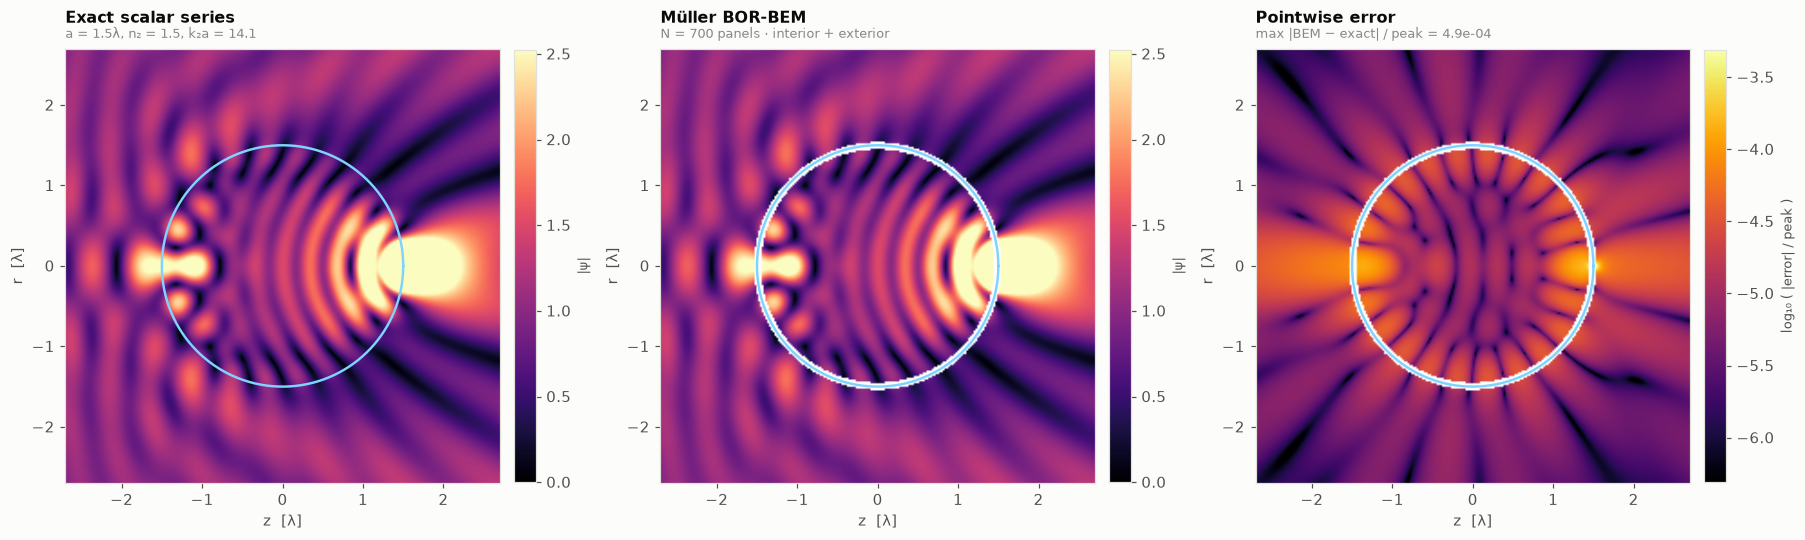

In [5]:
BC = load("ball_comparison")
a_c = float(BC["a"])
inside_c = BC["inside"]
valid = inside_c | BC["outside"] if "outside" in BC else inside_c

fig, ax = plt.subplots(1, 3, figsize=(16.5, 5.0))
circ = np.linspace(0, 2 * np.pi, 400)

rr_ex, PP_ex = mirror(BC["rg"], BC["psi_exact"])
vmax = np.nanpercentile(np.abs(PP_ex), 97)

for i, (D, title, sub) in enumerate([
        (BC["psi_exact"], "Exact scalar series",
         f"a = {a_c}λ, n₂ = {float(BC['n2'])}, "
         f"k₂a = {float(BC['k2a']):.1f}"),
        (BC["psi_bem"], "Müller BOR-BEM",
         f"N = {int(BC['N'])} panels · interior + exterior")]):
    rr, PP = mirror(BC["rg"], D)
    im = ax[i].imshow(np.abs(PP),
                      extent=[BC["zg"][0], BC["zg"][-1], rr[0], rr[-1]],
                      origin="lower", aspect="equal", cmap="magma",
                      vmin=0, vmax=vmax, interpolation="bilinear")
    ax[i].plot(a_c * np.cos(circ), a_c * np.sin(circ), color=EDGE, lw=1.6)
    ax[i].set_xlabel("z  [λ]"); ax[i].set_ylabel("r  [λ]")
    ax[i].grid(False)
    plt.colorbar(im, ax=ax[i], fraction=0.046, pad=0.03).set_label(
        "|ψ|", fontsize=8.5)
    ttl(ax[i], title, sub)

err = np.abs(BC["psi_bem"] - BC["psi_exact"])
peak = np.abs(BC["psi_exact"][valid]).max()
err_rel = np.full_like(err, np.nan)
err_rel[valid] = err[valid] / peak
rr_e, EE = mirror(BC["rg"], err_rel)
emax = np.log10(max(err[valid].max() / peak, 1e-6))
emin = emax - 3.0
im = ax[2].imshow(np.log10(np.maximum(np.abs(EE), 10**emin)),
                  extent=[BC["zg"][0], BC["zg"][-1], rr_e[0], rr_e[-1]],
                  origin="lower", aspect="equal", cmap="inferno",
                  vmin=emin, vmax=emax, interpolation="bilinear")
ax[2].plot(a_c * np.cos(circ), a_c * np.sin(circ), color=EDGE, lw=1.6)
ax[2].set_xlabel("z  [λ]"); ax[2].set_ylabel("r  [λ]")
ax[2].grid(False)
plt.colorbar(im, ax=ax[2], fraction=0.046, pad=0.03).set_label(
    "log₁₀ ( |error| / peak )", fontsize=8.5)
ttl(ax[2], "Pointwise error",
    f"max |BEM − exact| / peak = {err[valid].max()/peak:.1e}")
plt.tight_layout(); plt.show()

The error is set by $k_2a$, not by the contrast or by the mesh: at
64–100 panels per interior wavelength the surface error crosses 1 % around
$k_2a\approx 40$ for both indices, and the conditioning of the Müller
operator degrades past it.  Every ovoid run in these notebooks stays well
inside that range.